# Vietnam Statistical Arbitrage: PCA + OU Mean Reversion
## Baseline Notebook (Long-Only + VN30 Futures Hedge)

This notebook implements a statistical arbitrage strategy for Vietnam stocks:
- **Factor Model**: Rolling PCA on stock returns
- **Signal**: OU/AR(1) mean-reversion fitted to residuals
- **Portfolio**: Long-only, equal-weight, VN30-hedged
- **Goal**: Validate the research pipeline before optimization

Pipeline:
1. Data loading & preprocessing
2. Universe definition
3. Rolling PCA factor extraction
4. Residual construction
5. OU/AR(1) mean-reversion fitting
6. S-score signal generation
7. Long-only signal logic
8. Equal-weight portfolio construction
9. VN30 futures hedge computation
10. Backtest engine
11. Performance analysis & diagnostics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Libraries loaded successfully.
Pandas: 2.2.3
NumPy: 2.3.2


# SECTION 1: Data Loading and Preprocessing
## Vietnam stocks + VN30 futures prices, volumes, and returns

In [3]:
## Define date range
START_DATE = '2018-01-02'
END_DATE   = '2025-12-31'

print(f'Analysis period: {START_DATE} to {END_DATE}\n')

## Load Vietnam stock prices
stock_price_df = pd.read_csv('vietnam_stocks_price.csv', index_col=0, parse_dates=True)
print(f'Stock price shape: {stock_price_df.shape}')
print(f'Stock price date range: {stock_price_df.index.min().date()} to {stock_price_df.index.max().date()}')
print(f'Stock price missing (total): {stock_price_df.isna().sum().sum()}\n')

## Load Vietnam stock volumes
stock_volume_df = pd.read_csv('vietnam_stocks_volume.csv', index_col=0, parse_dates=True)
print(f'Stock volume shape: {stock_volume_df.shape}')
print(f'Stock volume date range: {stock_volume_df.index.min().date()} to {stock_volume_df.index.max().date()}\n')

## Load VN30 futures prices
fu_vn30_df = pd.read_csv('fu_vn30_price.csv', index_col=0, parse_dates=True)
print(f'VN30 futures shape: {fu_vn30_df.shape}')
print(f'VN30 futures date range: {fu_vn30_df.index.min().date()} to {fu_vn30_df.index.max().date()}\n')

Analysis period: 2018-01-02 to 2025-12-31

Stock price shape: (2872, 702)
Stock price date range: 2014-07-09 to 2025-12-31
Stock price missing (total): 248600

Stock volume shape: (2872, 702)
Stock volume date range: 2014-07-09 to 2025-12-31

VN30 futures shape: (2141, 5)
VN30 futures date range: 2017-08-10 to 2026-03-11



In [4]:
# =========================
# FIX 2: clean stock data without creating fake tradability
# =========================
missing_pct = stock_price_df.isna().mean() * 100
stocks_to_keep = missing_pct[missing_pct <= 5].index

print(f"Removing {len(stock_price_df.columns) - len(stocks_to_keep)} stocks with >5% missing data")
print(f"Keeping {len(stocks_to_keep)} stocks initially")

stock_price_clean = stock_price_df[stocks_to_keep].copy()
stock_volume_clean = stock_volume_df[stocks_to_keep].copy()

# Do NOT forward-fill prices or volume for trading logic

valid_ratio = stock_price_clean.notna().mean()
stocks_final = valid_ratio[valid_ratio >= 0.95].index

stock_price_clean = stock_price_clean[stocks_final].copy()
stock_volume_clean = stock_volume_clean[stocks_final].copy()

print(f"After secondary filter: {len(stocks_final)} stocks")
print(f"Price shape: {stock_price_clean.shape}")
print(f"Volume shape: {stock_volume_clean.shape}")

# =========================
# FIX 1: choose VN30 futures close explicitly
# =========================
if isinstance(fu_vn30_df, pd.DataFrame):
    lower_map = {str(c).lower(): c for c in fu_vn30_df.columns}

    if 'close' in lower_map:
        vn30_price_aligned = fu_vn30_df[lower_map['close']].copy()
    elif 'settlement price' in lower_map:
        vn30_price_aligned = fu_vn30_df[lower_map['settlement price']].copy()
    else:
        raise ValueError(
            f"Cannot identify futures close column. Available columns: {list(fu_vn30_df.columns)}"
        )
else:
    vn30_price_aligned = fu_vn30_df.copy()

vn30_price_aligned.name = 'VN30_FUT_CLOSE'
print("Using VN30 futures series:", vn30_price_aligned.name)

# =========================
# FIX 3: align dates and build tradability mask
# =========================
common_dates = (
    stock_price_clean.index
    .intersection(stock_volume_clean.index)
    .intersection(vn30_price_aligned.index)
)

stock_price = stock_price_clean.loc[common_dates].copy()
stock_volume = stock_volume_clean.loc[common_dates].copy()
vn30_price = vn30_price_aligned.loc[common_dates].copy()

tradable_mask = (
    stock_price.notna() &
    stock_volume.notna() &
    (stock_volume > 0)
)

print("Aligned stock price shape:", stock_price.shape)
print("Aligned stock volume shape:", stock_volume.shape)
print("Aligned VN30 futures shape:", vn30_price.shape)
print("Tradable entries:", tradable_mask.sum().sum())

Removing 276 stocks with >5% missing data
Keeping 426 stocks initially
After secondary filter: 426 stocks
Price shape: (2872, 426)
Volume shape: (2872, 426)
Using VN30 futures series: VN30_FUT_CLOSE
Aligned stock price shape: (2098, 426)
Aligned stock volume shape: (2098, 426)
Aligned VN30 futures shape: (2098,)
Tradable entries: 769288


In [5]:
# =========================
# FIX 5: compute returns only where both days are tradable
# =========================
stock_returns_raw = stock_price.pct_change()
vn30_returns = vn30_price.pct_change()

tradable_return_mask = tradable_mask & tradable_mask.shift(1)

stock_returns = stock_returns_raw.where(tradable_return_mask)
stock_returns = stock_returns.dropna(how='all')

vn30_returns = vn30_returns.dropna()

common_dates = stock_returns.index.intersection(vn30_returns.index)

stock_returns = stock_returns.loc[common_dates]
vn30_returns = vn30_returns.loc[common_dates]
stock_price = stock_price.loc[common_dates]
stock_volume = stock_volume.loc[common_dates]
tradable_mask = tradable_mask.loc[common_dates]

print("Stock returns shape:", stock_returns.shape)
print("VN30 returns shape:", vn30_returns.shape)

## Summary statistics
print('Stock returns summary:')
print(f'  Mean: {stock_returns.mean().mean():.6f}')
print(f'  Std:  {stock_returns.std().mean():.6f}')
print(f'  Min:  {stock_returns.min().min():.6f}')
print(f'  Max:  {stock_returns.max().max():.6f}\n')

print('VN30 returns summary:')
print(f'  Mean: {vn30_returns.mean():.6f}')
print(f'  Std:  {vn30_returns.std():.6f}')
print(f'  Min:  {vn30_returns.min():.6f}')
print(f'  Max:  {vn30_returns.max():.6f}')

Stock returns shape: (2097, 426)
VN30 returns shape: (2097,)
Stock returns summary:
  Mean: inf
  Std:  0.031406
  Min:  -1.000000
  Max:  inf

VN30 returns summary:
  Mean: 0.000589
  Std:  0.014873
  Min:  -0.110069
  Max:  0.069971


# SECTION 2: Universe Definition
## Define trading universe based on liquidity filters
Universe logic: select top N stocks by average volume over a rolling window

In [6]:
def select_liquid_universe(price_df, volume_df, date, top_n=300, lookback_window=366):
    """
    Select top N stocks by liquidity on a given date.
    
    Args:
        price_df: DataFrame of stock prices
        volume_df: DataFrame of stock volumes
        date: Trading date
        top_n: Number of top liquid stocks to select
        lookback_window: Days to look back for liquidity calculation
        
    Returns:
        price_window: Clean price data for selected stocks
        volume_window: Clean volume data for selected stocks
    """
    # Filter stocks with price data available on the given date
    stocks_available = price_df.loc[date].notna()
    
    # Get lookback window
    window_start = date - pd.Timedelta(days=lookback_window)
    price_window = price_df.loc[window_start:date, stocks_available].copy()
    volume_window = volume_df.loc[window_start:date, stocks_available].copy()
    
    # Calculate average volume (most recent day)
    latest_volume = volume_window.iloc[-1]  # Most recent volume
    top_stocks = latest_volume.nlargest(top_n).index.tolist()
    
    # Clean: forward-fill, drop rows with any missing in final selection
    price_window = price_window[top_stocks].ffill(limit=2)
    price_window = price_window.dropna(axis=1, how='any')
    
    final_stocks = price_window.columns
    volume_window = volume_window[final_stocks].ffill(limit=5)
    
    return price_window, volume_window

## Test universe selection on a recent date
test_date = stock_price.index[-100]  # 100 days before end
test_price, test_volume = select_liquid_universe(stock_price, stock_volume, test_date, top_n=100)
print(f'Universe selection test (date={test_date.date()}):')
print(f'  Selected {len(test_price.columns)} liquid stocks')
print(f'  Price data shape: {test_price.shape}')
print(f'  Volume data shape: {test_volume.shape}')

Universe selection test (date=2025-08-12):
  Selected 100 liquid stocks
  Price data shape: (250, 100)
  Volume data shape: (250, 100)


# SECTION 3: Rolling PCA Factor Extraction
## Compute PCA factors on rolling estimation window
Strategy: standardize returns, compute empirical correlation, perform eigendecomposition

In [7]:
def standardize_returns(ret_window):
    """
    Standardize returns: Y_ik = (R_ik - mean_i) / std_i per stock
    """
    mean_per_stock = ret_window.mean(axis=0)
    std_per_stock = ret_window.std(axis=0, ddof=1).replace(0, np.nan)
    Y = (ret_window - mean_per_stock) / std_per_stock
    return Y.dropna(axis=1)  # drop any stock with zero std

def compute_correlation_matrix(Y):
    """
    Compute empirical correlation from standardized returns
    """
    M = Y.shape[0]  # number of observations
    return (Y.values.T @ Y.values) / (M - 1)

def eigen_decomposition_sorted(corr_matrix):
    """
    Eigendecomposition with eigenvalues sorted descending
    """
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

# =========================
# FIX 6: robust rolling PCA
# =========================
def rolling_pca(returns, estimation_window=252, n_factors=5, min_stocks=20):
    dates = returns.index
    pca_dict = {}

    for t in range(estimation_window, len(dates)):
        trading_date = dates[t]

        est_start = t - estimation_window
        est_end = t
        ret_window = returns.iloc[est_start:est_end].copy()

        ret_window = ret_window.dropna(axis=1, how='any')
        if ret_window.shape[1] < min_stocks:
            continue

        mean_per_stock = ret_window.mean(axis=0)
        std_per_stock = ret_window.std(axis=0, ddof=1)

        valid_cols = std_per_stock[std_per_stock > 1e-12].index
        ret_window = ret_window[valid_cols]
        mean_per_stock = mean_per_stock[valid_cols]
        std_per_stock = std_per_stock[valid_cols]

        if ret_window.shape[1] < min_stocks:
            continue

        Y = (ret_window - mean_per_stock) / std_per_stock
        corr = np.corrcoef(Y.values.T)

        eigvals, eigvecs = np.linalg.eigh(corr)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        k = min(n_factors, ret_window.shape[1] - 1)
        if k < 1:
            continue

        V = eigvecs[:, :k]
        Q = V / std_per_stock.values.reshape(-1, 1)

        pca_dict[trading_date] = {
            'Q': Q,
            'stocks': ret_window.columns.tolist(),
            'k': k,
            'eigvals': eigvals[:k],
        }

    return pca_dict

## Run rolling PCA
print("Running rolling PCA...")
pca_results = rolling_pca(stock_returns, estimation_window=252, n_factors=5, min_stocks=20)
print(f"PCA available for {len(pca_results)} dates")

Running rolling PCA...
PCA available for 1845 dates


# SECTION 4: Residual Construction
## Use PCA factors to compute fitted & residual returns

In [8]:
# =========================
# FIX 7: correct residual regression
# =========================
def compute_residuals(returns, pca_dict, regression_window=60, min_obs=40):
    dates = returns.index
    residuals = pd.DataFrame(index=dates, columns=returns.columns, dtype=float)

    for trading_date in sorted(pca_dict.keys()):
        if trading_date not in dates:
            continue

        t = dates.get_loc(trading_date)
        if t < regression_window:
            continue

        pca_info = pca_dict[trading_date]
        Q = pca_info['Q']
        stocks = pca_info['stocks']

        reg_start = t - regression_window
        reg_end = t
        R_reg_df = returns.iloc[reg_start:reg_end][stocks].copy()

        valid_rows = R_reg_df.notna().all(axis=1)
        R_reg_df = R_reg_df.loc[valid_rows]

        if R_reg_df.shape[0] < min_obs:
            continue

        R_reg = R_reg_df.values
        F_reg = R_reg @ Q

        X = np.column_stack([np.ones(R_reg.shape[0]), F_reg])

        r_today = returns.loc[trading_date, stocks]
        if r_today.isna().any():
            continue

        r_today = r_today.values
        f_today = r_today @ Q
        x_today = np.concatenate([[1.0], f_today])

        try:
            beta_all = np.linalg.lstsq(X, R_reg, rcond=None)[0]
        except np.linalg.LinAlgError:
            continue

        fitted_ret = x_today @ beta_all

        for i, stock in enumerate(stocks):
            residuals.loc[trading_date, stock] = r_today[i] - fitted_ret[i]

    return residuals

print("Computing residuals...")
residuals = compute_residuals(stock_returns, pca_results, regression_window=60, min_obs=40)
print("Residuals shape:", residuals.shape)
print("Residual missing:", residuals.isna().sum().sum())

Computing residuals...
Residuals shape: (2097, 426)
Residual missing: 574819


# SECTION 5: OU/AR(1) Mean Reversion Fitting
## Fit Ornstein-Uhlenbeck model to residuals to estimate mean-reversion parameters

In [9]:
# =========================
# FIX 8: robust OU fitting
# =========================
def fit_ou_model(residuals, window=60, limit=False, kappa_min=8.4, min_obs=40):
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()

    for col in residuals.columns:
        series = residuals[col]

        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()

            if len(eps_win) < min_obs:
                continue

            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue

            x_prev = Xcum[:-1]
            x_next = Xcum[1:]

            A = np.column_stack([np.ones(len(x_prev)), x_prev])

            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except np.linalg.LinAlgError:
                continue

            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)

            if not np.isfinite(b) or not np.isfinite(var_xi):
                continue
            if var_xi <= 1e-12:
                continue
            if b <= 0 or b >= 0.999999:
                continue

            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))

            if not np.isfinite(kappa_val) or not np.isfinite(mu_val) or not np.isfinite(sigma_eq_val):
                continue
            if sigma_eq_val <= 1e-12:
                continue
            if limit and kappa_val < kappa_min:
                continue

            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val

    return kappa, mu, sigma_eq

## Fit OU model (without kappa filter first)
print('Fitting OU model to residuals (limit=False)...')
kappa_df, mu_df, sigma_eq_df = fit_ou_model(residuals=residuals, window=60, limit=False, kappa_min=8.4)
print(f'OU parameters created')
print(f'Kappa median: {kappa_df.stack().median():.2f} (annualized)')
print(f'Sigma_eq median: {sigma_eq_df.stack().median():.6f}')

Fitting OU model to residuals (limit=False)...
OU parameters created
Kappa median: 26.75 (annualized)
Sigma_eq median: 0.041692


# SECTION 6: S-Score Signal Generation
## Compute standardized signal from residuals and OU parameters

In [10]:
# =========================
# FIX 9: stable s-score computation
# =========================
def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    s = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)

    for col in residuals.columns:
        eps = residuals[col]

        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue

            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]

            if pd.isna(mu_t) or pd.isna(sigma_t) or sigma_t <= 1e-12:
                continue

            s.iloc[t, s.columns.get_loc(col)] = (x_t - mu_t) / sigma_t

    return s

## Compute s-scores
print('Computing s-scores...')
sscore_df = compute_s_score(residuals, mu_df, sigma_eq_df, window=60)
print(f'S-score shape: {sscore_df.shape}')
print(f'S-score median: {sscore_df.stack().median():.4f}')
print(f'S-score std: {sscore_df.stack().std():.4f}')

Computing s-scores...
S-score shape: (2097, 426)
S-score median: -0.0429
S-score std: 1.4319


# SECTION 7: Long-Only Signal Logic
## Generate long-only trading signals based on s-score thresholds

Trading rules (long-only baseline):
- Open long: when s-score falls below -threshold (stock oversold/undervalued)
- Close long: when s-score rises above -close_threshold (mean-reversion towards equilibrium)

In [22]:
# =========================
# FIX 10: long-only signals with forced flat on invalid data
# =========================
def generate_signals_long_only(s_df, tradable_mask=None, s_open=1.25, s_close=0.50):
    signals = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    current = pd.Series(0, index=s_df.columns, dtype=int)

    for t in range(1, len(s_df.index)):
        date = s_df.index[t]
        prev_date = s_df.index[t - 1]

        s_prev = s_df.loc[prev_date]

        if tradable_mask is not None:
            tradable_today = tradable_mask.loc[date].reindex(s_df.columns).fillna(False)
        else:
            tradable_today = pd.Series(True, index=s_df.columns)

        for stock in s_df.columns:
            val = s_prev[stock]

            if pd.isna(val) or (not tradable_today[stock]):
                current[stock] = 0
                continue

            if current[stock] == 0:
                if val < -s_open:
                    current[stock] = 1
            else:
                if val > -s_close:
                    current[stock] = 0

        signals.loc[date] = current.values

    return signals

## Generate signals
print('Generating long-only signals...')
signals_df = generate_signals_long_only(sscore_df, s_open=1.25, s_close=0.50)
print(f'Signals shape: {signals_df.shape}')
total_long_signal_days = (signals_df == 1).sum().sum()
print(f'Total long signal-days: {total_long_signal_days}')
print(f'Avg positions per day: {(signals_df == 1).sum().mean():.2f}')

Generating long-only signals...
Signals shape: (2097, 426)
Total long signal-days: 59899
Avg positions per day: 140.61


# SECTION 8: Equal-Weight Portfolio Construction
## Build equal-weight long-only portfolio from signals

Portfolio rules:
- Equal weight across all active long positions on each date
- No leverage, no optimization
- Simple and transparent construction

In [23]:
# =========================
# FIX 11: equal-weight portfolio with strongest-signal ranking
# =========================
def construct_portfolio(signals_df, s_df=None, max_positions=None):
    weights = pd.DataFrame(0.0, index=signals_df.index, columns=signals_df.columns)

    for date in signals_df.index:
        active = signals_df.loc[date]
        long_stocks = active[active == 1].index.tolist()

        if len(long_stocks) == 0:
            continue

        if max_positions is not None and len(long_stocks) > max_positions:
            if s_df is not None and date in s_df.index:
                ranked = s_df.loc[date, long_stocks].sort_values()
                long_stocks = ranked.index[:max_positions].tolist()
            else:
                long_stocks = long_stocks[:max_positions]

        w = 1.0 / len(long_stocks)
        weights.loc[date, long_stocks] = w

    return weights

## Construct portfolio
print('Constructing equal-weight portfolio...')
weights_df = construct_portfolio(signals_df, max_positions=None)
print(f'Weights shape: {weights_df.shape}')
print(f'Avg weight per date: {weights_df.sum(axis=1).mean():.4f}')  # Should be ~1.0 on long days
print(f'Sample weights sum (first 5 long days):')
long_days = weights_df[weights_df.sum(axis=1) > 0].head(5)
print(long_days.sum(axis=1))

Constructing equal-weight portfolio...
Weights shape: (2097, 426)
Avg weight per date: 0.8584
Sample weights sum (first 5 long days):
2018-10-17    1.0
2018-10-18    1.0
2018-10-19    1.0
2018-10-22    1.0
2018-10-23    1.0
dtype: float64


# SECTION 9: VN30 Futures Hedge Computation
## Compute rolling beta and hedge VN30 systematic risk with short futures

In [24]:
# =========================
# FIX 12: rolling beta without look-ahead
# =========================
def compute_rolling_beta(stock_portfolio_returns, vn30_returns, beta_window=60):
    common_idx = stock_portfolio_returns.index.intersection(vn30_returns.index)
    R_stock = stock_portfolio_returns.loc[common_idx]
    R_vn30 = vn30_returns.loc[common_idx]

    beta_series = pd.Series(np.nan, index=common_idx)

    for t in range(beta_window, len(common_idx)):
        date = common_idx[t]

        stock_window = R_stock.iloc[t - beta_window:t]
        vn30_window = R_vn30.iloc[t - beta_window:t]

        valid = stock_window.notna() & vn30_window.notna()
        stock_window = stock_window[valid]
        vn30_window = vn30_window[valid]

        if len(stock_window) < max(20, beta_window // 2):
            continue

        var_vn30 = np.var(vn30_window, ddof=1)
        if var_vn30 <= 1e-12:
            beta_series.loc[date] = 0.0
            continue

        cov = np.cov(stock_window, vn30_window)[0, 1]
        beta_series.loc[date] = cov / var_vn30

    return beta_series

## Compute portfolio returns and beta
print('Computing rolling beta for hedge sizing...')

# Portfolio stock returns (when long)
portfolio_returns = (weights_df * stock_returns).sum(axis=1)

# Rolling beta
beta_series = compute_rolling_beta(portfolio_returns, vn30_returns, beta_window=60)

print(f'Portfolio returns shape: {portfolio_returns.shape}')
print(f'Beta series shape: {beta_series.shape}')
print(f'Mean beta: {beta_series.mean():.4f}')
print(f'Median beta: {beta_series.median():.4f}')
print(f'Std beta: {beta_series.std():.4f}')

Computing rolling beta for hedge sizing...
Portfolio returns shape: (2097,)
Beta series shape: (2097,)
Mean beta: 0.5922
Median beta: 0.6155
Std beta: 0.3209


# SECTION 10: Backtest Engine
## Single clean backtest for PCA + long-only portfolio + VN30 hedge

In [25]:
def backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series, 
                      initial_equity=100, slippage=0.0005):
    """
    Backtest long-only stock portfolio + VN30 futures hedge.
    
    Daily equity update:
    - Stock leg: position weights * stock returns
    - Hedge leg: -beta * vn30 returns (short futures)
    - Slippage: on position changes
    
    Args:
        weights_df: Portfolio weights
        stock_returns: Stock returns
        vn30_returns: VN30 futures returns
        beta_series: Rolling beta
        initial_equity: Starting equity
        slippage: Transaction cost factor
        
    Returns:
        equity_curve: Series of daily equity values
    """
    # Align data
    common_idx = (weights_df.index
                  .intersection(stock_returns.index)
                  .intersection(vn30_returns.index)
                  .intersection(beta_series.index))
    
    w = weights_df.loc[common_idx].fillna(0)
    r_stock = stock_returns.loc[common_idx].fillna(0)
    r_vn30 = vn30_returns.loc[common_idx].fillna(0)
    beta = beta_series.loc[common_idx].fillna(0)
    
    # Initialize equity curve
    equity = pd.Series(initial_equity, index=common_idx)
    
    for t in range(1, len(common_idx)):
        date_t = common_idx[t]
        date_prev = common_idx[t - 1]
        
        E_prev = equity.iloc[t - 1]
        
        # Current equity and positions
        w_today = w.loc[date_t]
        beta_today = beta.loc[date_t]
        r_stock_today = r_stock.loc[date_t]
        r_vn30_today = r_vn30.loc[date_t]
        
        # Stock leg position (in dollars)
        Q_stock = E_prev * w_today
        
        # VN30 futures hedge (short, sized by beta)
        Q_vn30 = -E_prev * beta_today
        
        # PnL
        pnl_stock = (Q_stock * r_stock_today).sum()
        pnl_vn30 = Q_vn30 * r_vn30_today
        
        # Transaction costs (only on position changes)
        if t > 1:
            w_prev = w.loc[date_prev]
            beta_prev = beta.loc[date_prev]
            Q_stock_prev = equity.iloc[t - 2] * w_prev
            Q_vn30_prev = -equity.iloc[t - 2] * beta_prev
        else:
            Q_stock_prev = pd.Series(0, index=w.columns)
            Q_vn30_prev = 0
        
        cost = ((Q_stock - Q_stock_prev).abs().sum() + abs(Q_vn30 - Q_vn30_prev)) * slippage
        
        # Update equity
        equity.iloc[t] = E_prev + pnl_stock + pnl_vn30 - cost
    
    return equity

## Run backtest
print('Running backtest...')
equity_curve = backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series,
                                   initial_equity=100, slippage=0.0005)

print(f'\nBacktest Results:')
print(f'  Starting equity: {equity_curve.iloc[0]:.2f}')
print(f'  Ending equity: {equity_curve.iloc[-1]:.2f}')
print(f'  Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%')

Running backtest...

Backtest Results:
  Starting equity: 100.00
  Ending equity: 182.22
  Total return: 82.22%


# SECTION 11: Performance Analysis and Diagnostics
## Compute Sharpe ratio, portfolio metrics, and validation diagnostics

In [26]:
def compute_sharpe_ratio(equity_curve, trading_days=252):
    """
    Arnualized Sharpe ratio from equity curve.
    """
    daily_returns = equity_curve.pct_change().dropna()
    if len(daily_returns) < 2:
        return np.nan
    
    mean_ret = daily_returns.mean()
    std_ret = daily_returns.std()
    
    if std_ret < 1e-10:
        return np.nan
    
    return np.sqrt(trading_days) * mean_ret / std_ret

def compute_annual_sharpe(daily_returns, trading_days=252):
    """
    Annual Sharpe by year.
    """
    daily_returns = daily_returns.copy()
    daily_returns.index = pd.to_datetime(daily_returns.index)
    
    years = sorted(daily_returns.index.year.unique())
    result = {}
    
    for year in years:
        data = daily_returns[daily_returns.index.year == year].dropna()
        if len(data) < 20:
            result[year] = np.nan
        else:
            std = data.std()
            result[year] = np.sqrt(trading_days) * data.mean() / std if std > 1e-10 else np.nan
    
    return pd.Series(result)

## Equity curve analysis
daily_ret = equity_curve.pct_change().dropna()
total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
total_sharpe = compute_sharpe_ratio(equity_curve)
annual_sharpe = compute_annual_sharpe(daily_ret)

print('\n' + '='*60)
print('BACKTEST SUMMARY')
print('='*60)
print(f'Period: {equity_curve.index.min().date()} to {equity_curve.index.max().date()}')
print(f'Initial Equity: ${equity_curve.iloc[0]:.2f}')
print(f'Final Equity: ${equity_curve.iloc[-1]:.2f}')
print(f'\nTotal Return: {total_return:.2f}%')
print(f'Total Sharpe Ratio: {total_sharpe:.3f}')
print(f'\nDaily Return Stats:')
print(f'  Mean: {daily_ret.mean()*100:.4f}%')
print(f'  Std: {daily_ret.std()*100:.4f}%')
print(f'  Min: {daily_ret.min()*100:.4f}%')
print(f'  Max: {daily_ret.max()*100:.4f}%')
print(f'\nSharpe by Year:')
print(annual_sharpe.round(3))
print('='*60)


BACKTEST SUMMARY
Period: 2017-08-11 to 2025-12-31
Initial Equity: $100.00
Final Equity: $182.22

Total Return: 82.22%
Total Sharpe Ratio: 0.546

Daily Return Stats:
  Mean: 0.0333%
  Std: 0.9684%
  Min: -4.8230%
  Max: 5.1105%

Sharpe by Year:
2017      NaN
2018    0.046
2019   -0.342
2020    1.817
2021    2.976
2022    0.156
2023    1.623
2024   -1.294
2025   -1.618
dtype: float64


In [27]:
## Portfolio metrics
active_positions_per_day = (weights_df > 0).sum(axis=1)
max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

print('\n' + '='*60)
print('PORTFOLIO METRICS')
print('='*60)
print(f'Active long positions (average): {active_positions_per_day.mean():.1f}')
print(f'Max active positions (1 day): {active_positions_per_day.max():.0f}')
print(f'Days with 0 positions: {(active_positions_per_day == 0).sum()}')
print(f'\nBeta Hedge:')
print(f'  Mean beta: {beta_series.mean():.4f}')
print(f'  Median beta: {beta_series.median():.4f}')
print(f'  Max drawdown: {max_dd*100:.2f}%')
print('='*60)


PORTFOLIO METRICS
Active long positions (average): 28.6
Max active positions (1 day): 58
Days with 0 positions: 297

Beta Hedge:
  Mean beta: 0.5922
  Median beta: 0.6155
  Max drawdown: 33.28%


In [28]:
beta_series.describe()

count    2037.000000
mean        0.592159
std         0.320893
min         0.000000
25%         0.393371
50%         0.615530
75%         0.811075
max         1.320197
dtype: float64

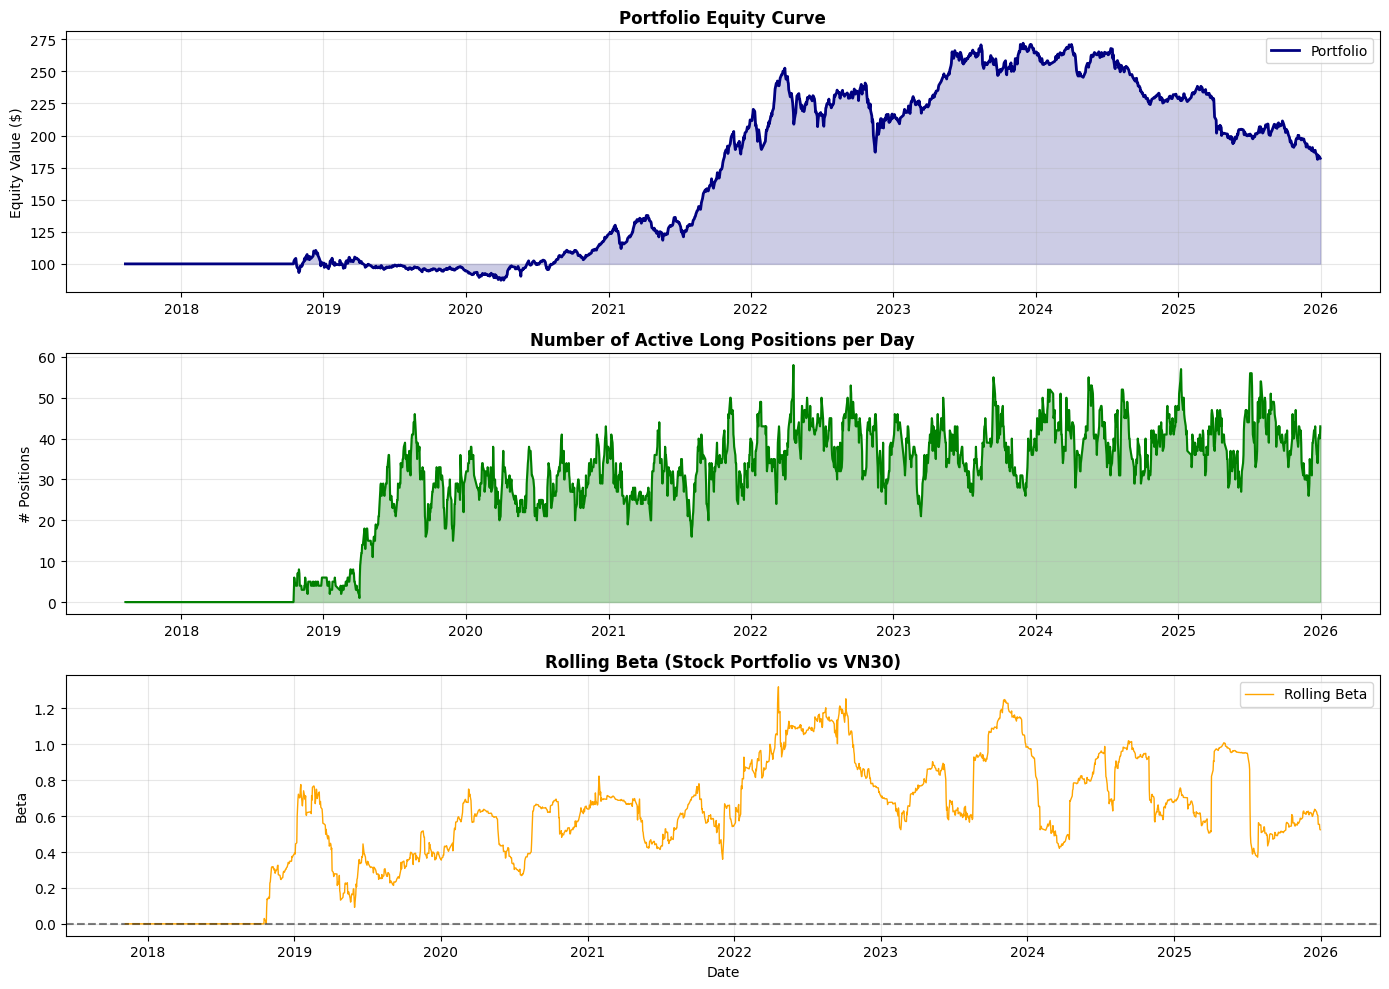

Plots complete.


In [29]:
## Plot equity curve
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Equity curve
ax = axes[0]
ax.plot(equity_curve.index, equity_curve.values, linewidth=2, color='navy', label='Portfolio')
ax.fill_between(equity_curve.index, equity_curve.iloc[0], equity_curve.values, alpha=0.2, color='navy')
ax.set_title('Portfolio Equity Curve', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity Value ($)')
ax.grid(True, alpha=0.3)
ax.legend()

# Active positions over time
ax = axes[1]
ax.plot(active_positions_per_day.index, active_positions_per_day.values, linewidth=1.5, color='green')
ax.fill_between(active_positions_per_day.index, 0, active_positions_per_day.values, alpha=0.3, color='green')
ax.set_title('Number of Active Long Positions per Day', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.grid(True, alpha=0.3)

# Rolling beta
ax = axes[2]
ax.plot(beta_series.index, beta_series.values, linewidth=1, color='orange', label='Rolling Beta')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Rolling Beta (Stock Portfolio vs VN30)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Beta')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print('Plots complete.')

In [30]:
# =========================
# FIX 14: diagnostic report
# =========================
def diagnostic_report(
    weights_df,
    s_df,
    beta_series,
    equity_curve,
    bt_details,
    tradable_mask
):
    active_positions = (weights_df > 0).sum(axis=1)
    daily_ret = equity_curve.pct_change().dropna()

    max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

    held_and_tradable = (
        (weights_df > 0) &
        tradable_mask.reindex_like(weights_df).fillna(False)
    ).sum(axis=1)

    held_total = (weights_df > 0).sum(axis=1).replace(0, np.nan)
    tradable_fraction = (held_and_tradable / held_total).dropna()

    ann_ret = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (252 / max(len(daily_ret), 1)) - 1 if len(daily_ret) > 0 else np.nan
    ann_vol = daily_ret.std() * np.sqrt(252) if len(daily_ret) > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and ann_vol > 1e-12 else np.nan

    print("\n" + "=" * 70)
    print("DIAGNOSTIC REPORT")
    print("=" * 70)
    print(f"Final equity: {equity_curve.iloc[-1]:.2f}")
    print(f"Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%")
    print(f"Annualized return: {ann_ret * 100:.2f}%" if pd.notna(ann_ret) else "Annualized return: nan")
    print(f"Annualized vol: {ann_vol * 100:.2f}%" if pd.notna(ann_vol) else "Annualized vol: nan")
    print(f"Sharpe: {sharpe:.3f}" if pd.notna(sharpe) else "Sharpe: nan")
    print(f"Max drawdown: {max_dd * 100:.2f}%")
    print(f"Avg active positions: {active_positions.mean():.2f}")
    print(f"Median beta: {beta_series.median():.4f}")
    print(f"Avg cost/day: {bt_details['cost'].mean():.4f}")
    print(f"Avg tradable fraction of held positions: {tradable_fraction.mean():.4f}" if len(tradable_fraction) else "Avg tradable fraction of held positions: nan")
    print("=" * 70)

In [31]:
diagnostic_report(
    weights_df=weights_df,
    s_df=sscore_df,
    beta_series=beta_series,
    equity_curve=equity_curve,
    bt_details={'cost': (weights_df.diff().abs().sum(axis=1) + beta_series.diff().abs()) * 0.0005},
    tradable_mask=tradable_mask
)


DIAGNOSTIC REPORT
Final equity: 182.22
Total return: 82.22%
Annualized return: 7.48%
Annualized vol: 15.37%
Sharpe: 0.487
Max drawdown: 33.28%
Avg active positions: 28.56
Median beta: 0.6155
Avg cost/day: 0.0001
Avg tradable fraction of held positions: 0.9986


## Summary: Baseline Pipeline Validation

This notebook implements a complete baseline Vietnam statistical arbitrage strategy:

✅ **Completed Steps:**
1. Data loading: Vietnam stocks + VN30 futures, clean & aligned
2. Universe: Simple liquidity-based selection
3. PCA: Rolling factor extraction without look-ahead bias
4. Residuals: Factor-adjusted returns
5. OU fitting: Mean-reversion speed estimation
6. S-score: Standardized mean-reversion signal
7. Signals: Long-only trading rules (no shorts)
8. Portfolio: Equal-weight construction (no optimization)
9. Hedge: Rolling beta-based VN30 futures short position
10. Backtest: Single clean function, transaction costs included
11. Outputs: Equity curve, Sharpe ratio, diagnostics

**Next Steps for Optimization:**
- Adjust PCA parameters (window, number of factors)
- Tune signal thresholds (s_open, s_close)
- Explore kappa filteri (limit=True with kappa_min)
- Add position sizing optimization
- Improve hedge efficiency
- Reduce transaction costs
- Walk-forward backtesting

**Current Status:** ✓ Conceptually correct, runnable, minimal optimization
**Validation Goal:** Ensure pipeline produces sensible results before parameter tuning

Last 5 trading dates: [Timestamp('2025-12-25 00:00:00'), Timestamp('2025-12-26 00:00:00'), Timestamp('2025-12-29 00:00:00'), Timestamp('2025-12-30 00:00:00'), Timestamp('2025-12-31 00:00:00')]



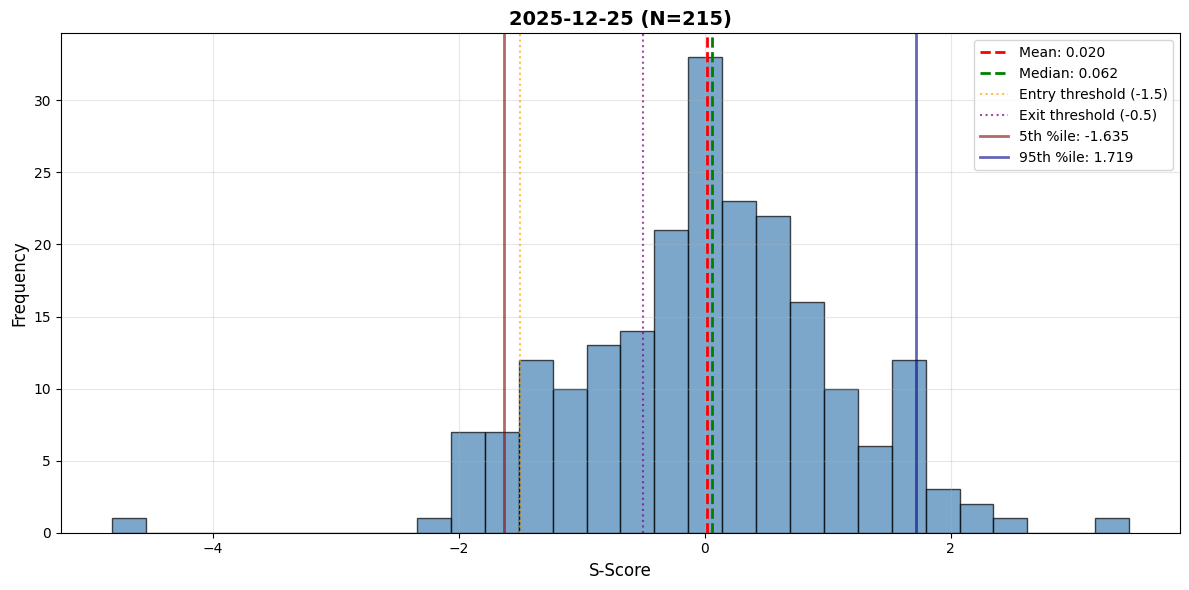

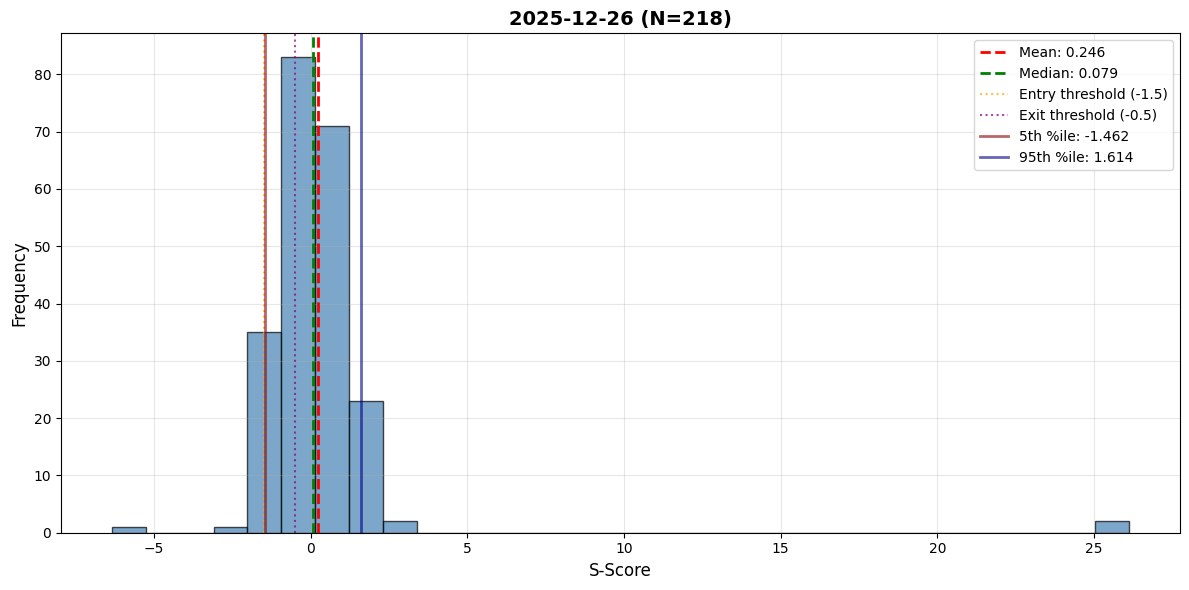

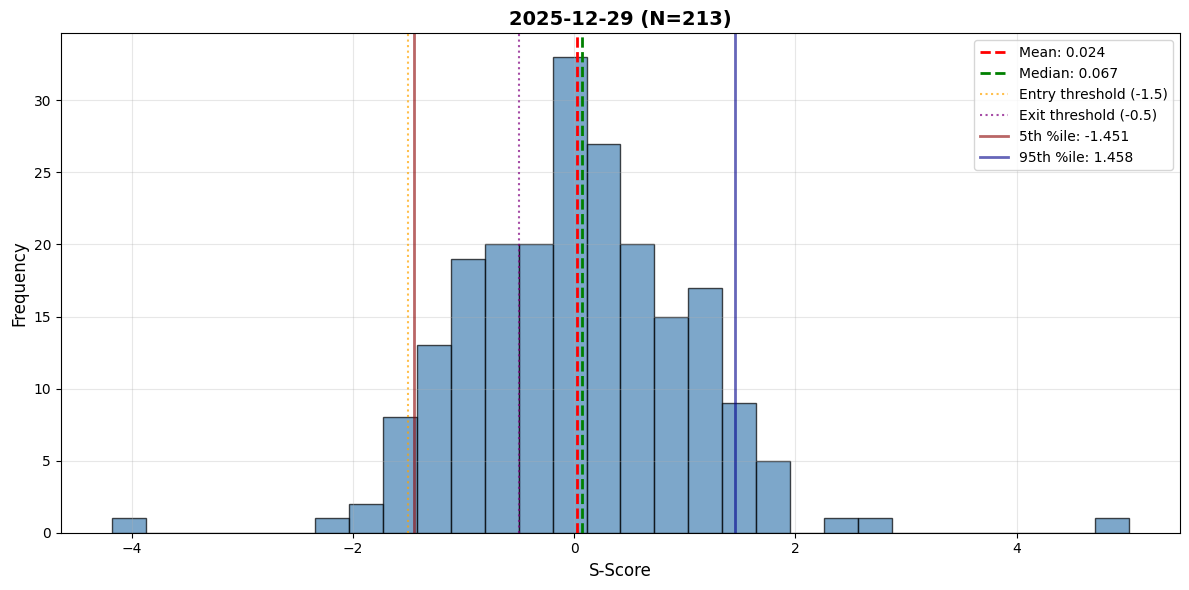

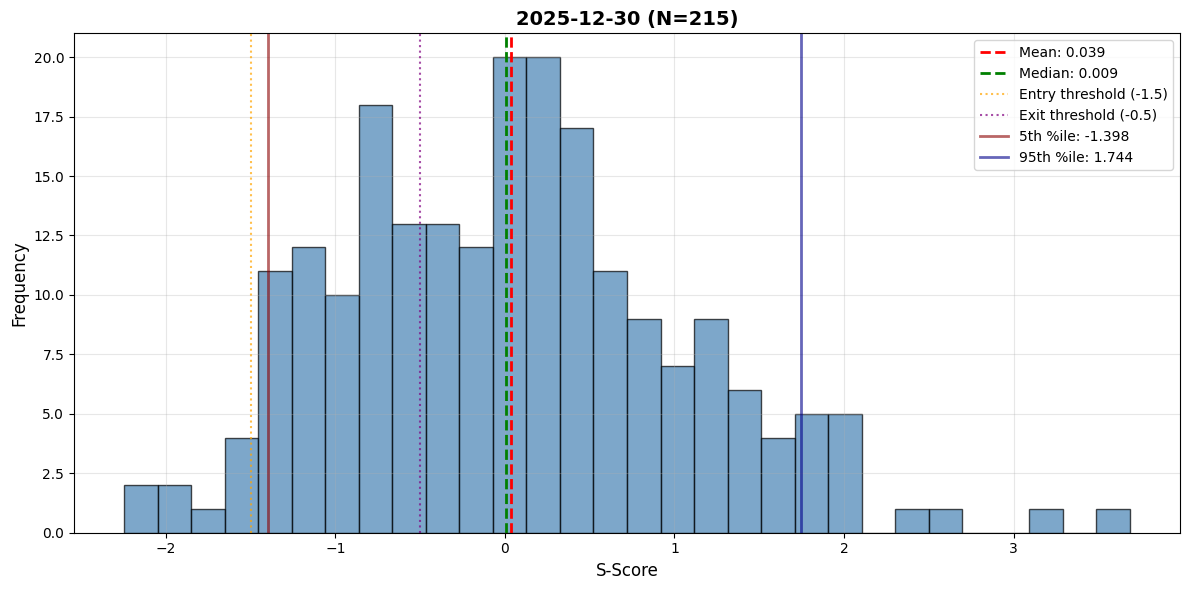

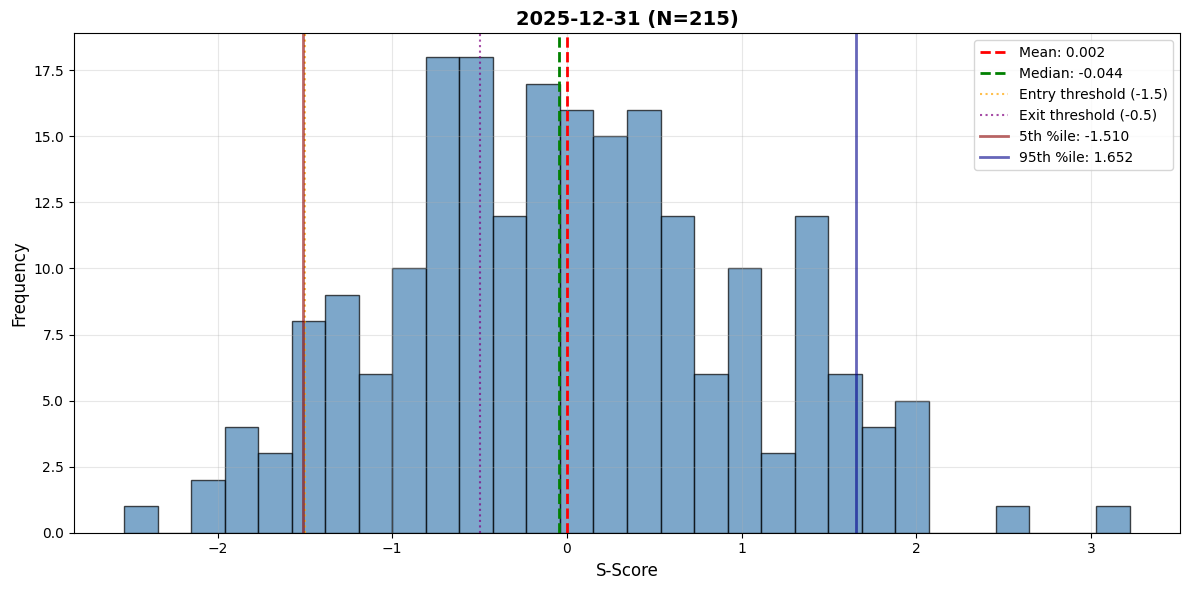


S-Score Distribution Summary (Last 5 Days):

2025-12-25:
  Count: 215
  Mean: 0.0196
  Median: 0.0616
  Std: 1.0583
  Min: -4.8208
  Max: 3.4506
  5th percentile: -1.6348
  95th percentile: 1.7194
  % < -1.5 (buy signal): 7.4%
  % > -0.5 (sell signal): 71.2%

2025-12-26:
  Count: 218
  Mean: 0.2462
  Median: 0.0787
  Std: 2.6531
  Min: -6.3445
  Max: 26.1162
  5th percentile: -1.4619
  95th percentile: 1.6144
  % < -1.5 (buy signal): 4.1%
  % > -0.5 (sell signal): 70.6%

2025-12-29:
  Count: 213
  Mean: 0.0241
  Median: 0.0671
  Std: 1.0077
  Min: -4.1784
  Max: 5.0156
  5th percentile: -1.4505
  95th percentile: 1.4582
  % < -1.5 (buy signal): 4.2%
  % > -0.5 (sell signal): 70.0%

2025-12-30:
  Count: 215
  Mean: 0.0390
  Median: 0.0088
  Std: 1.0128
  Min: -2.2443
  Max: 3.6850
  5th percentile: -1.3977
  95th percentile: 1.7441
  % < -1.5 (buy signal): 3.7%
  % > -0.5 (sell signal): 67.0%

2025-12-31:
  Count: 215
  Mean: 0.0021
  Median: -0.0440
  Std: 0.9964
  Min: -2.5335
  Max:

In [36]:
## Plot S-Score Distribution for Last 5 Days (Individual Plots)
last_5_days = sscore_df.tail(5)
print(f"Last 5 trading dates: {last_5_days.index.tolist()}\n")

# Day 1
date = last_5_days.index[0]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(-1.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (-1.5)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 2
date = last_5_days.index[1]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(-1.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (-1.5)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 3
date = last_5_days.index[2]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(-1.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (-1.5)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 4
date = last_5_days.index[3]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(-1.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (-1.5)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Day 5
date = last_5_days.index[4]
s_values = last_5_days.loc[date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(s_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {s_values.median():.3f}')
ax.axvline(-1.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='Entry threshold (-1.5)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.6, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.6, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'{date.date()} (N={len(s_values)})', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nS-Score Distribution Summary (Last 5 Days):")
print("=" * 70)
for date in last_5_days.index:
    s_values = last_5_days.loc[date].dropna()
    p5 = s_values.quantile(0.05)
    p95 = s_values.quantile(0.95)
    print(f"\n{date.date()}:")
    print(f"  Count: {len(s_values)}")
    print(f"  Mean: {s_values.mean():.4f}")
    print(f"  Median: {s_values.median():.4f}")
    print(f"  Std: {s_values.std():.4f}")
    print(f"  Min: {s_values.min():.4f}")
    print(f"  Max: {s_values.max():.4f}")
    print(f"  5th percentile: {p5:.4f}")
    print(f"  95th percentile: {p95:.4f}")
    print(f"  % < -1.5 (buy signal): {(s_values < -1.5).sum() / len(s_values) * 100:.1f}%")
    print(f"  % > -0.5 (sell signal): {(s_values > -0.5).sum() / len(s_values) * 100:.1f}%")